# **Zomato Delivery Time Prediction using Linear Regression**

# **1. Problem Statement**

The objective of this project is to develop a **Linear Regression** model to predict the **food delivery time (`Time_taken (min)`)** using various factors related to the order, delivery partner, vehicle, weather, traffic conditions, and delivery location.

The project aims to:

* Predict the delivery time for food orders.
* Identify the key factors influencing delivery duration.
* Perform data preprocessing and feature engineering to prepare the dataset.
* Build and evaluate a Linear Regression model using appropriate regression metrics.
* Analyze the model's performance and interpret the results.

**Target Variable:** `Time_taken (min)`


## **2. Environment setup**

We import every library we will need up front. `statsmodels` is used alongside `scikit-learn` because it prints a full statistical summary (p-values, confidence intervals) that is convenient for teaching the *inference* side of linear regression.

In [8]:
# Core numerical / data handling
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics / hypothesis testing
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# scikit-learn: imputation, preprocessing, modelling, metrics
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (needed to expose IterativeImputer)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import radians

# Cosmetic settings
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")

Libraries imported successfully.


## **3. Data import and first look**

We load the raw CSV and take a first glance. At this stage we make **no** changes - we only observe.

In [9]:
# Load the raw dataset
df=pd.read_csv('C:\\Users\\HP USER\\Desktop\\Zomato\\Zomato Dataset.csv')

In [10]:
#first five record
df.head(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [11]:
#last five records
df.tail(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
45579,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35,11:45,Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,32
45580,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55,20:10,Windy,Jam,0,Buffet,motorcycle,1.0,No,Metropolitian,36
45581,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50,24:05:00,Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,16
45582,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35,13:40,Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,26
45583,0x5fb2,RANCHIRES09DEL02,23.0,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10,17:15,Fog,Medium,2,Snack,scooter,1.0,No,Metropolitian,36


## **4. Data statistics BEFORE cleaning**

Before touching anything we capture the "raw" state of the data:

* data types (`info`)
* summary statistics for numeric columns (`describe`)
* summary for categorical columns
* count and percentage of missing values

Recording this snapshot lets us show learners exactly what changed after cleaning.

In [12]:
# Data types, non-null counts and memory footprint
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  str    
 1   Delivery_person_ID           45584 non-null  str    
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  str    
 9   Time_Orderd                  43853 non-null  str    
 10  Time_Order_picked            45584 non-null  str    
 11  Weather_conditions           44968 non-null  str    
 12  Road_traffic_density         44983 non-null  str    
 13  Vehicle_condition          

In [13]:
# Statistical summary of NUMERIC columns (count, mean, std, min, quartiles, max)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Delivery_person_Age,43730.0,29.566911,5.815064,15.000000,25.000000,30.000000,35.000000,50.000000
Delivery_person_Ratings,43676.0,4.633774,0.334744,1.000000,4.500000,4.700000,4.900000,6.000000
Restaurant_latitude,45584.0,17.017948,8.185674,-30.905562,12.933284,18.551440,22.728163,30.914057
Restaurant_longitude,45584.0,70.229684,22.885575,-88.366217,73.170000,75.897963,78.044095,88.433452
Delivery_location_latitude,45584.0,17.465480,7.335562,0.010000,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45584.0,70.844161,21.120578,0.010000,73.280000,76.002574,78.107044,88.563452
Vehicle_condition,45584.0,1.023385,0.839055,0.000000,0.000000,1.000000,2.000000,3.000000
multiple_deliveries,44591.0,0.744635,0.572510,0.000000,0.000000,1.000000,1.000000,3.000000
Time_taken (min),45584.0,26.293963,9.384298,10.000000,19.000000,26.000000,32.000000,54.000000


In [14]:
# Statistical summary of CATEGORICAL / object columns
df.describe(include="object").T

C:\Users\HP USER\AppData\Local\Temp\ipykernel_2828\3321205060.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
ID,45584,45584,0xcdcd,1
Delivery_person_ID,45584,1320,JAPRES11DEL02,67
Order_Date,45584,44,15-03-2022,1192
Time_Orderd,43853,176,21:55,461
Time_Order_picked,45584,193,21:30,495
Weather_conditions,44968,6,Fog,7653
Road_traffic_density,44983,4,Low,15476
Type_of_order,45584,4,Snack,11530
Type_of_vehicle,45584,4,motorcycle,26429
Festival,45356,2,No,44460


In [15]:
# Missing-value audit: count and percentage per column
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct":   (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)
missing[missing["missing_count"] > 0]

,missing_count,missing_pct
Delivery_person_Ratings,1908,4.19
Delivery_person_Age,1854,4.07
Time_Orderd,1731,3.80
City,1200,2.63
multiple_deliveries,993,2.18
Weather_conditions,616,1.35
Road_traffic_density,601,1.32
Festival,228,0.50


In [16]:
# Separate the columns by type - we will reuse these lists throughout
target = "Time_taken (min)"
numeric_cols = df.select_dtypes(include=np.number).columns.drop(target).tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Numeric features   :", numeric_cols)
print("Categorical features:", categorical_cols)
print("Target             :", target)

Numeric features   : ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries']
Categorical features: ['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']
Target             : Time_taken (min)


C:\Users\HP USER\AppData\Local\Temp\ipykernel_2828\2432306491.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


## **5. Exploratory Data Analysis (EDA) plots**

We visualise the data to build intuition:

* **Target distribution** - is the `time_taken(min)` skewed?
* **Numeric feature distributions** - histograms / KDE.
* **Categorical feature counts** - how balanced are the groups?
* **Feature vs target** - do obvious relationships jump out (e.g. Weather_conditions)?

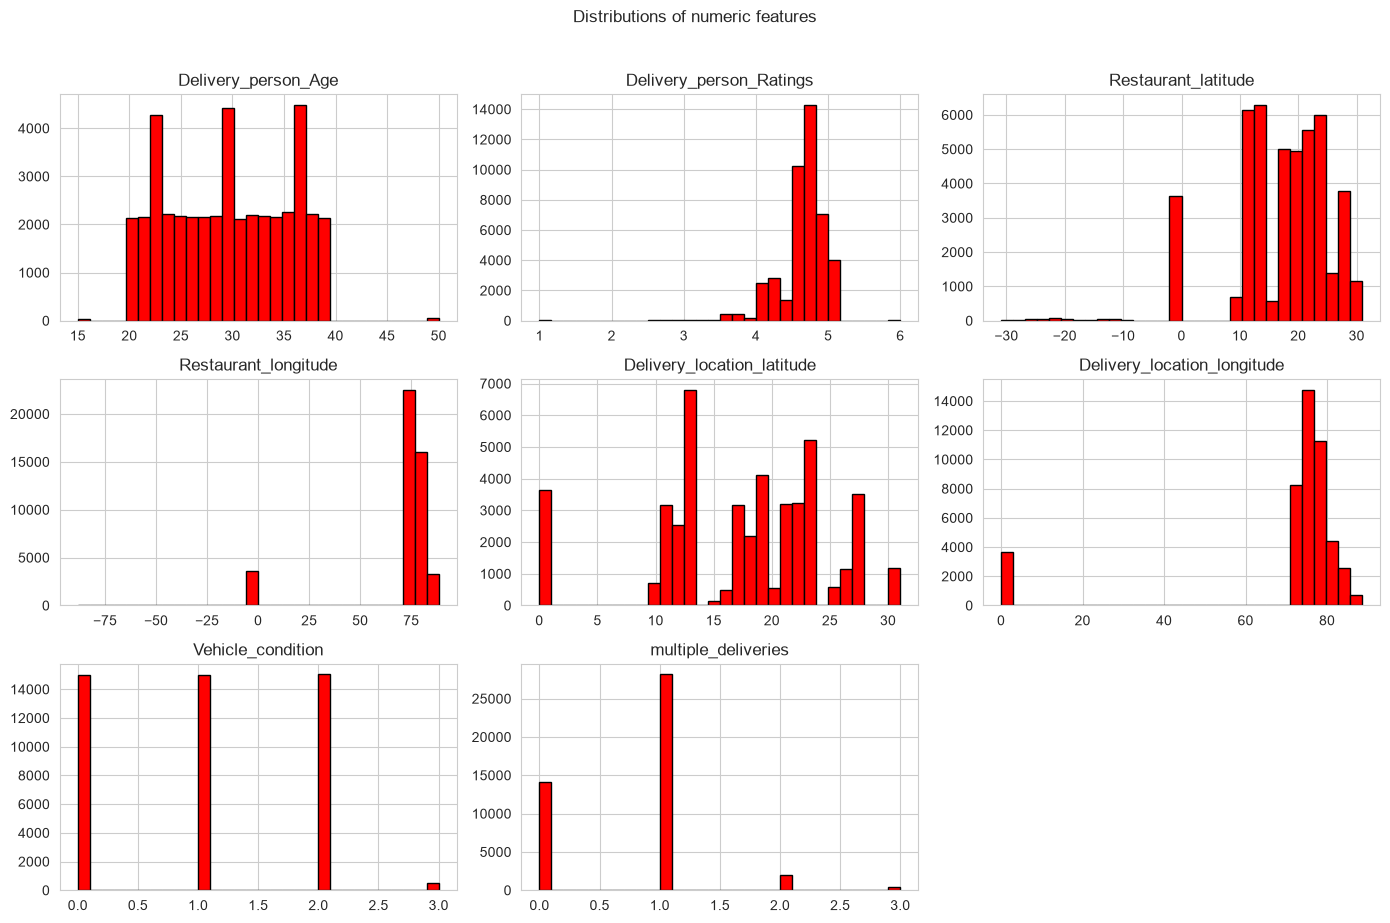

In [17]:
# plotting histogram for all the numaric columns
df[numeric_cols].hist(bins=30, figsize=(14, 9), color="red", edgecolor="black")
plt.suptitle("Distributions of numeric features", y=1.02)
plt.tight_layout(); plt.show()

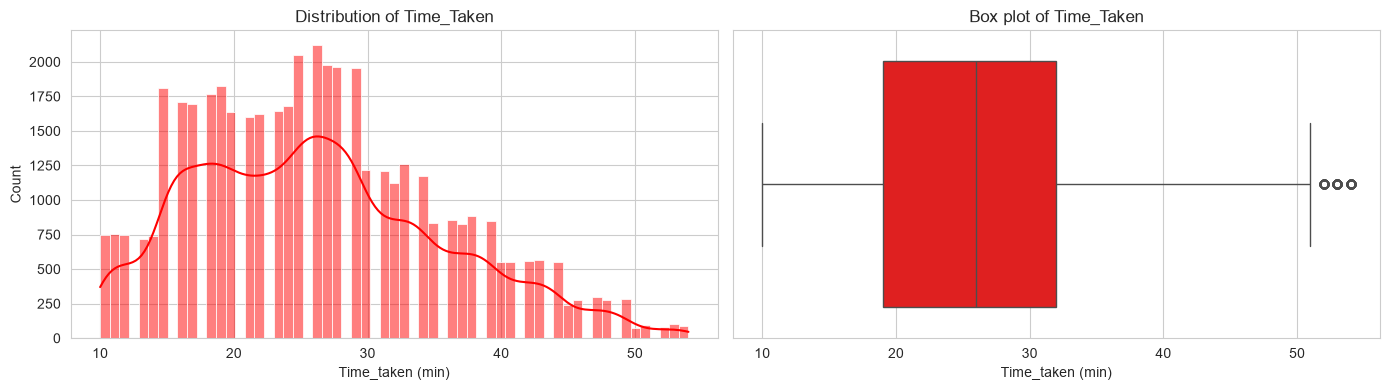

Skewness of target: 0.486


In [18]:
#Distribution of the target variable
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[target], kde=True, ax=ax[0], color="red")
ax[0].set_title("Distribution of Time_Taken")
sns.boxplot(x=df[target], ax=ax[1], color="red")
ax[1].set_title("Box plot of Time_Taken")
plt.tight_layout(); plt.show()

print(f"Skewness of target: {df[target].skew():.3f}")

C:\Users\HP USER\AppData\Local\Temp\ipykernel_2828\3231240393.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="viridis")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_2828\3231240393.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="viridis")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_2828\3231240393.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="viridis")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_2828\3231240393.py:6: Futur

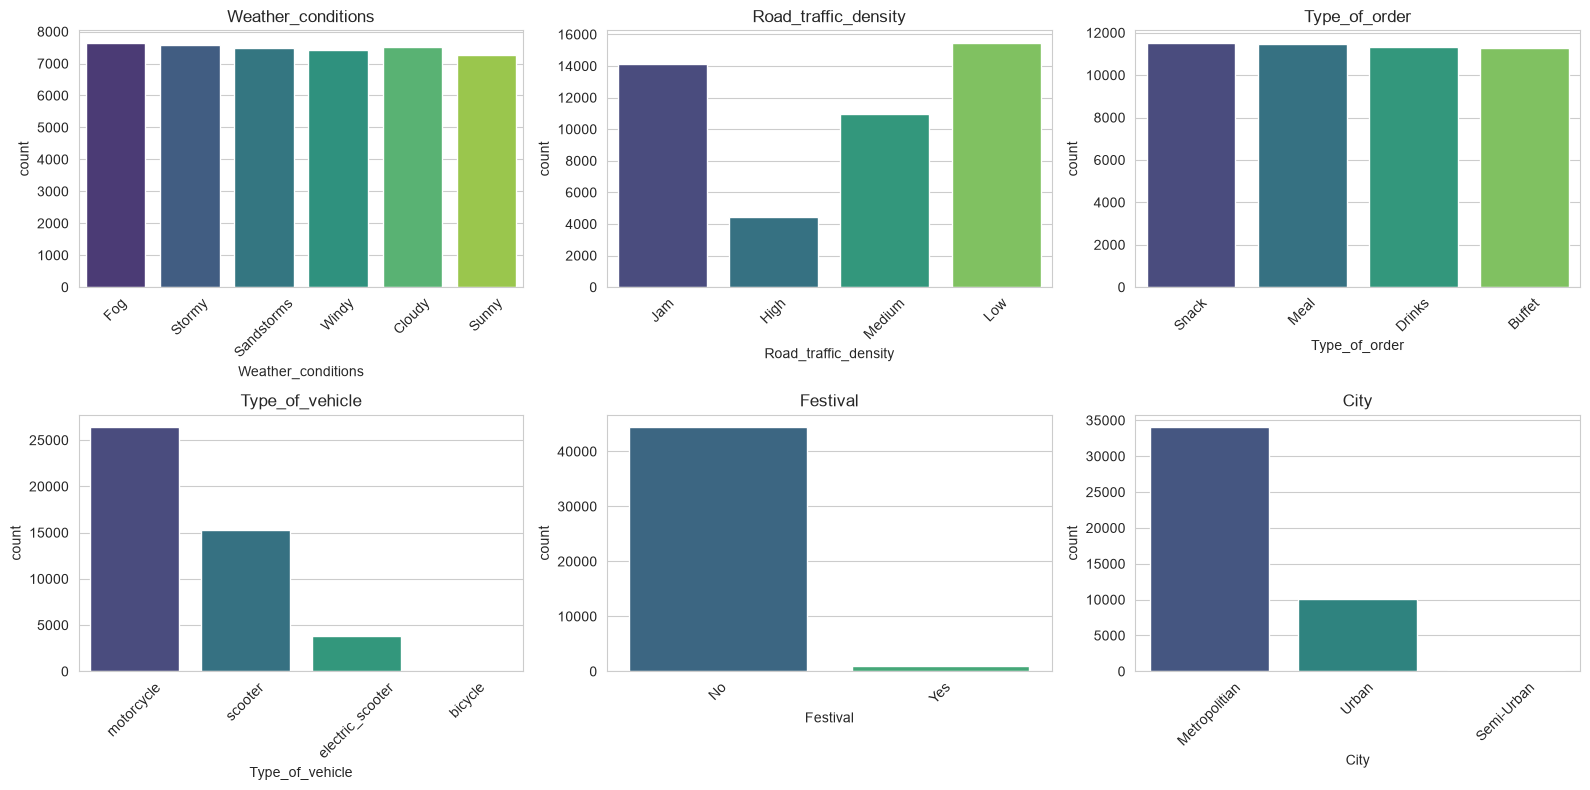

In [19]:
plot_cols = [col for col in categorical_cols
    if col not in ['ID','Delivery_person_ID','Order_Date','Time_Orderd','Time_Order_picked']]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, plot_cols):
    sns.countplot(data=df, x=col, ax=ax, palette="viridis")
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\HP USER\AppData\Local\Temp\ipykernel_2828\2812896295.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df, ax=ax, palette="Set2")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_2828\2812896295.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df, ax=ax, palette="Set2")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_2828\2812896295.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=df, ax=ax, palette="Set2")
C:\Users\HP USER\AppData\Local\Temp\ipykernel_2828\2812

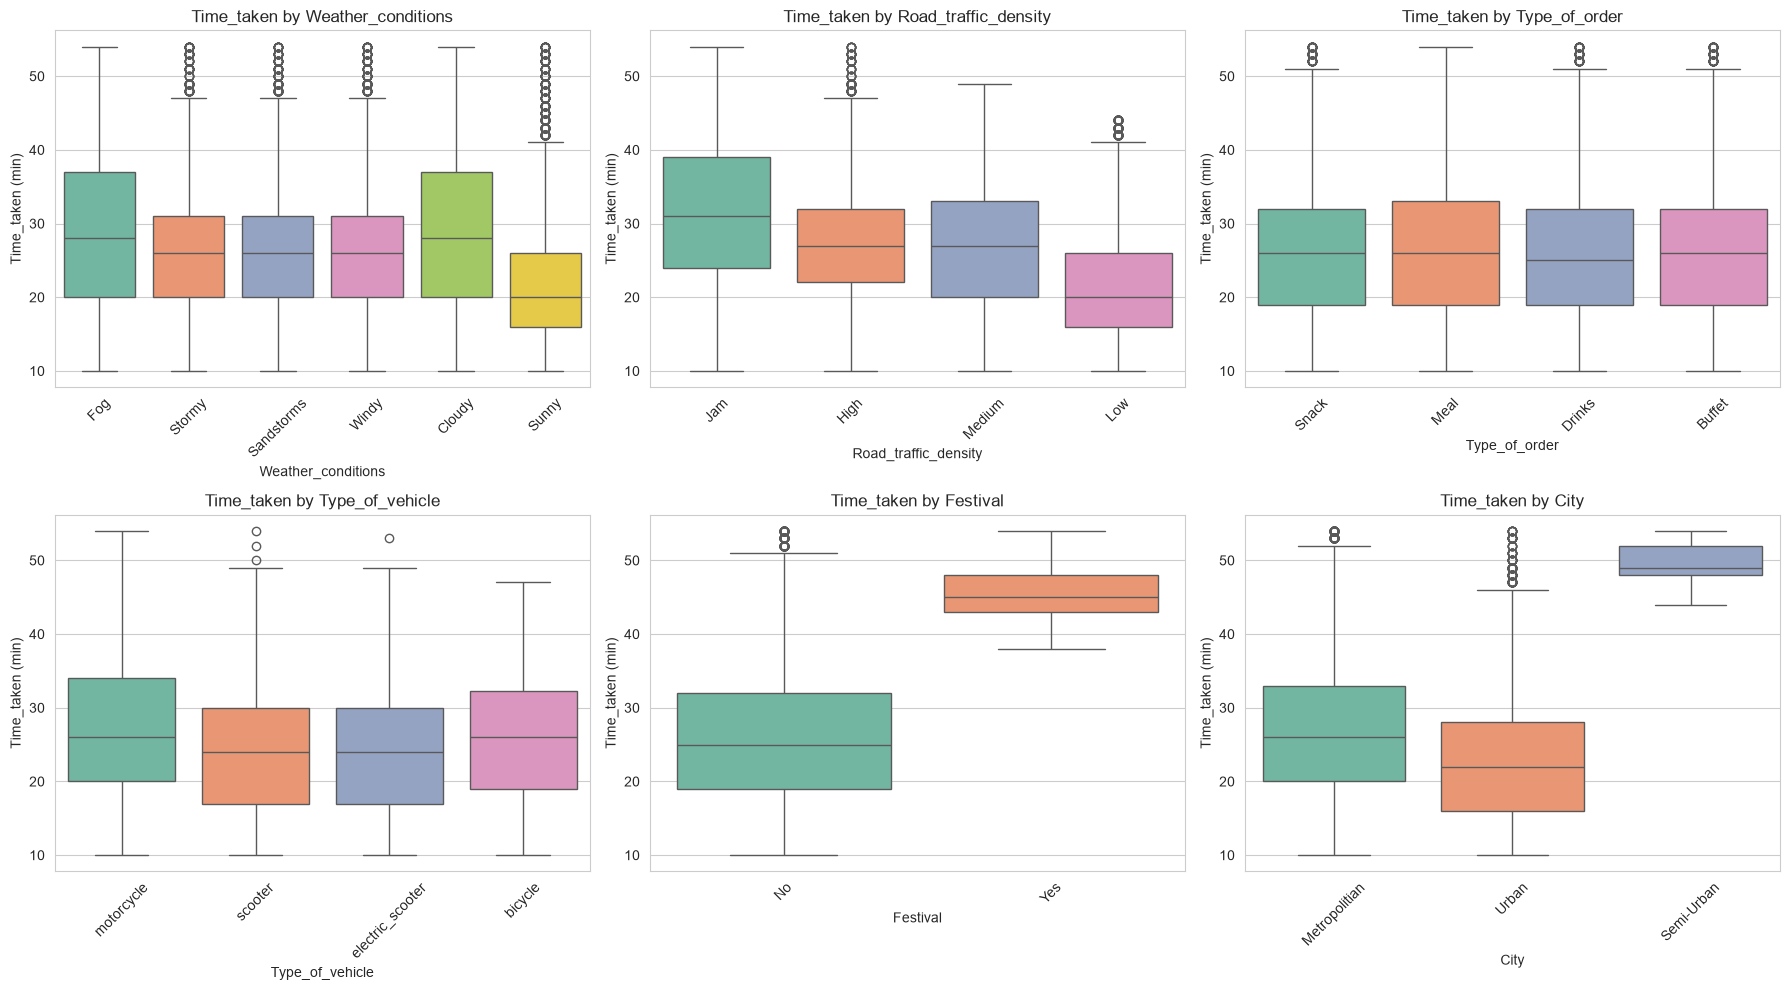

In [20]:
#How does the Time_taken differ across key categories?

cols = [
    "Weather_conditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.boxplot(x=col, y=target, data=df, ax=ax, palette="Set2")
    ax.set_title(f"Time_taken by {col}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

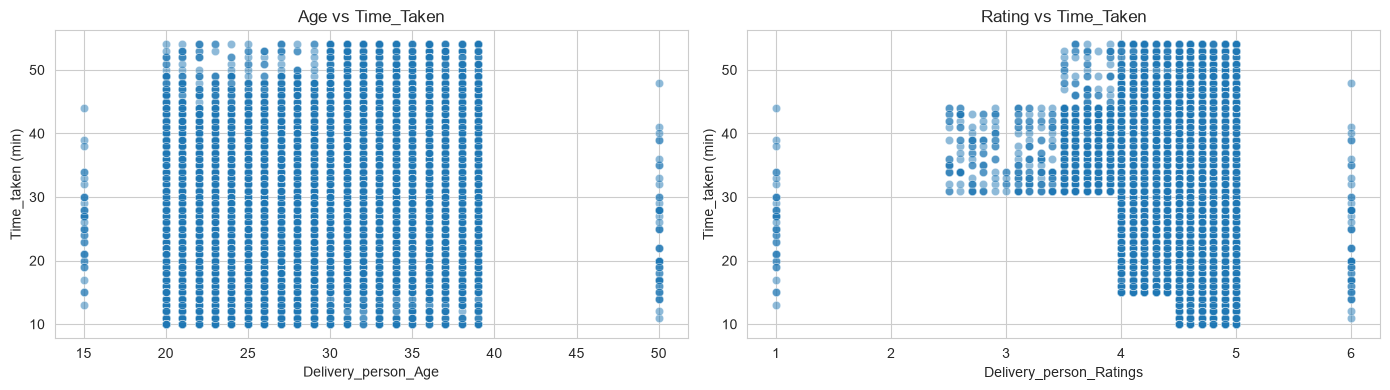

In [21]:
#Scatter of the two strongest expected numeric drivers vs Time_Taken
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.scatterplot(x="Delivery_person_Age", y=target,data=df, alpha=0.5, ax=axes[0])
axes[0].set_title("Age vs Time_Taken")
sns.scatterplot(x="Delivery_person_Ratings", y=target,data=df, alpha=0.5, ax=axes[1])
axes[1].set_title("Rating vs Time_Taken")
plt.tight_layout(); plt.show()

## **6.Correlations BEFORE cleaning**

We compute the Pearson correlation matrix on the numeric columns (dropping missing values pairwise for now). This is a *preliminary* view - we will recompute it after cleaning and compare.

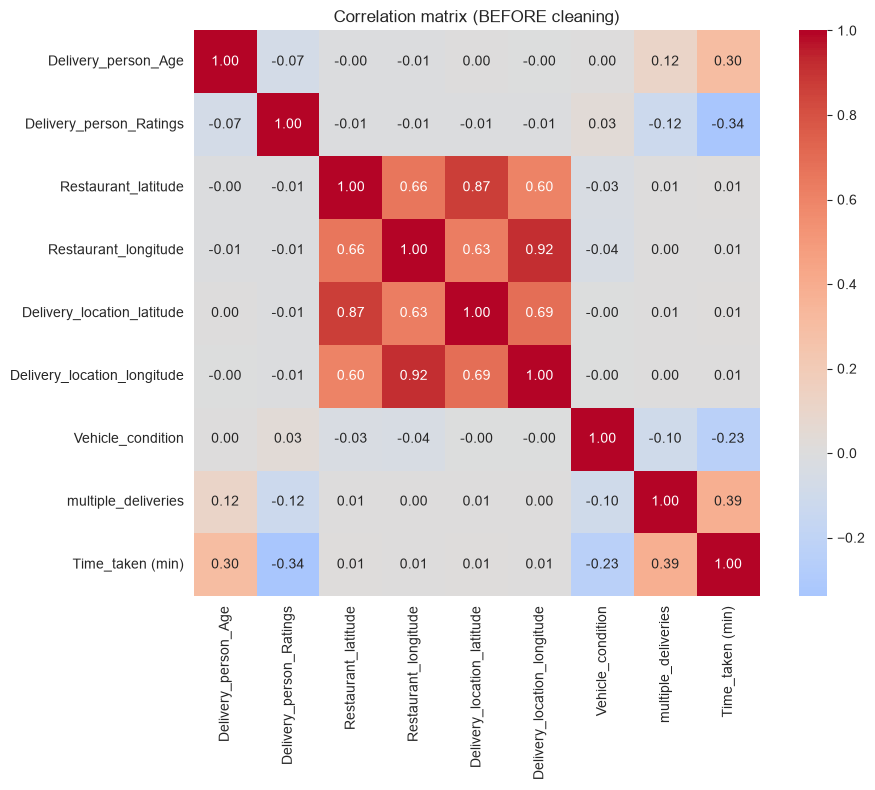

In [22]:
# Correlation matrix on raw numeric data (pandas ignores NaNs pairwise)
corr_before = df[numeric_cols + [target]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_before, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix (BEFORE cleaning)")
plt.tight_layout(); plt.show()

In [23]:
# Correlation of each feature WITH the target, ranked
corr_before[target].drop(target).sort_values(ascending=False)

multiple_deliveries            0.387042
Delivery_person_Age            0.299523
Delivery_location_latitude     0.014234
Restaurant_latitude            0.013970
Restaurant_longitude           0.007787
Delivery_location_longitude    0.007590
Vehicle_condition             -0.234456
Delivery_person_Ratings       -0.338814
Name: Time_taken (min), dtype: float64

## **7.Missing-value imputation**

We have missing values in several columns. We demonstrate the full toolkit and explain when each is appropriate, then commit to a sensible final strategy.

**Categorical columns** (`Weather_Conditions`, `Festival`) -> **mode** imputation (most frequent category).

**Numeric columns:**
* **Mean** imputation - fine for roughly symmetric distributions.
* **Median** imputation - preferred for skewed columns (e.g. income).


In [24]:
# Categorical: mode imputation (only apply to TRUE categoricals, not IDs/dates)
df_cln = df.copy()
true_categorical_cols = ["Weather_conditions", "Road_traffic_density",
                          "Type_of_order", "Type_of_vehicle", "Festival", "City"]
mode_imputer = SimpleImputer(strategy="most_frequent")
df_cln[true_categorical_cols] = mode_imputer.fit_transform(df_cln[true_categorical_cols])


In [25]:
# Numeric: median imputation (fixed — assigns back instead of broken inplace)
for col in numeric_cols:
    df_cln[col] = df_cln[col].fillna(df_cln[col].median())


In [26]:
# Fix restaurant lat/lon: correct sign errors and treat (0,0) as "keep, offset still valid"
df_cln["Restaurant_latitude"] = df_cln["Restaurant_latitude"].abs()
df_cln["Restaurant_longitude"] = df_cln["Restaurant_longitude"].abs()

assert df_cln[numeric_cols + true_categorical_cols].isna().sum().sum() == 0
print("Cleaning verified.")

Cleaning verified.


## **8. Correlations and scatter plots AFTER cleaning**

Now that the data is clean we recompute correlations and inspect the most important relationships. These are the correlations we actually trust and will carry into modelling.

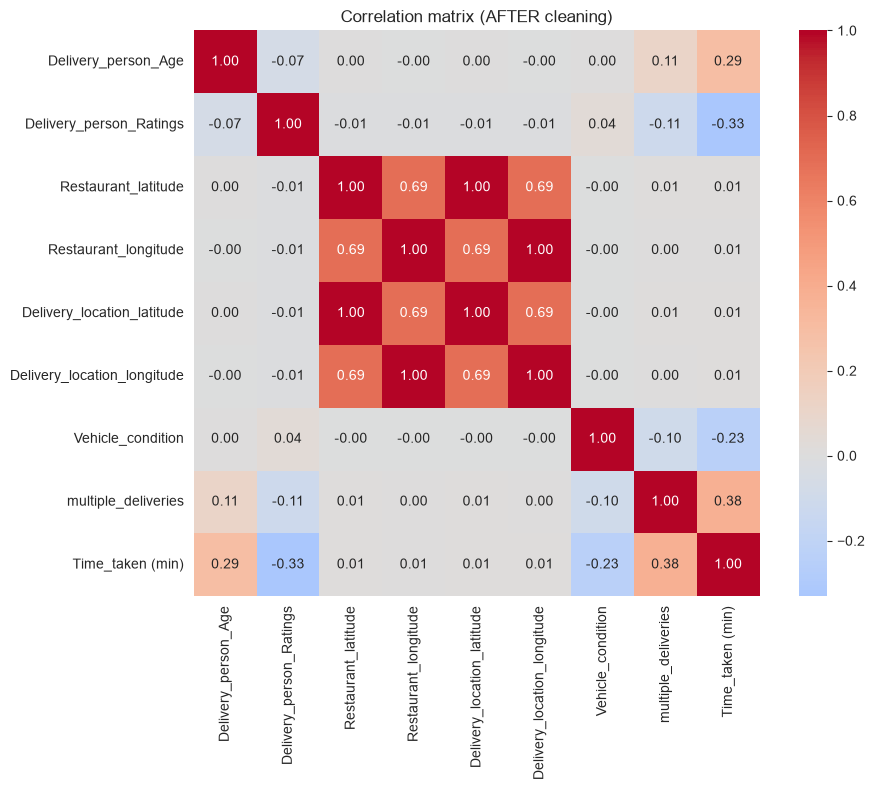

In [27]:
# 8a. Correlation heatmap on the CLEAN numeric data
corr_after = df_cln[numeric_cols + [target]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_after, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix (AFTER cleaning)")
plt.tight_layout(); plt.show()

In [28]:
# 8b. Ranked correlation with the target
corr_target = corr_after[target].drop(target).sort_values(ascending=False)
print("Correlation of each numeric feature with annual_premium:")
corr_target

Correlation of each numeric feature with annual_premium:


multiple_deliveries            0.378268
Delivery_person_Age            0.292909
Delivery_location_latitude     0.014234
Restaurant_latitude            0.012630
Delivery_location_longitude    0.007590
Restaurant_longitude           0.007032
Vehicle_condition             -0.234456
Delivery_person_Ratings       -0.330751
Name: Time_taken (min), dtype: float64

## **9.Feature Engineering**

raw columns aren't all directly useful for a regression model — some (like absolute latitude/longitude) carry almost no signal on their own, and some information is locked inside timestamps that need to be converted into numeric form. In this section we derive new features that better represent what actually drives delivery time.

* **`distance_km`** — straight-line distance between restaurant and delivery location, calculated using the Haversine formula. This replaces the four raw coordinate columns, which showed almost no correlation with the target individually (~0.01–0.014) — it's not *where* the points are, it's *how far apart* they are that matters.
* **`prep_time_min`** — the gap between `Time_Orderd` and `Time_Order_picked`, i.e. how long the order sat before a delivery partner picked it up. This is likely to be one of the strongest predictors of total delivery time.
* **`order_hour`** — the hour of day the order was placed, extracted from `Time_Orderd`, to capture peak vs. off-peak effects (e.g. lunch/dinner rush).
* **`day_of_week` / `is_weekend`** — extracted from `Order_Date`, to capture weekday vs. weekend ordering patterns.


In [29]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance between two lat/lon points, in kilometres."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

df_cln["distance_km"] = haversine_km(
    df_cln["Restaurant_latitude"], df_cln["Restaurant_longitude"],
    df_cln["Delivery_location_latitude"], df_cln["Delivery_location_longitude"]
)

df_cln["Order_Date"] = pd.to_datetime(df_cln["Order_Date"], format="%d-%m-%Y")
df_cln["order_day_of_week"] = df_cln["Order_Date"].dt.dayofweek
df_cln["order_hour"] = pd.to_datetime(df_cln["Time_Orderd"], format="%H:%M", errors="coerce").dt.hour
df_cln["order_hour"] = df_cln["order_hour"].fillna(df_cln["order_hour"].median())

df_cln.drop(columns=["ID", "Delivery_person_ID", "Order_Date",
                        "Time_Orderd", "Time_Order_picked",
                        "Restaurant_latitude", "Restaurant_longitude",
                        "Delivery_location_latitude", "Delivery_location_longitude"], inplace=True)

df_cln[["distance_km", "order_day_of_week", "order_hour"]].describe()

,distance_km,order_day_of_week,order_hour
count,45584.000000,45584.000000,45584.000000
mean,9.735119,2.997521,17.756515
std,5.608034,1.969709,4.254281
min,1.465067,0.000000,8.000000
25%,4.663345,1.000000,17.000000
50%,9.220148,3.000000,19.000000
75%,13.681492,5.000000,21.000000
max,20.969489,6.000000,23.000000


## **10.Outlier detection - IQR method and box plots**

We use the **Inter-Quartile Range (IQR)** rule to flag outliers:

* Q1 = 25th percentile, Q3 = 75th percentile, IQR = Q3 - Q1.
* A value is an outlier if it is **below Q1 - 1.5xIQR** or **above Q3 + 1.5xIQR**.

We first *count* outliers per feature, visualise them with box plots, then **cap** (winsorise) the extreme values rather than delete rows - capping keeps the sample size intact while removing the distorting effect of impossible values.

In [30]:
df_cln.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)', 'distance_km', 'order_day_of_week', 'order_hour'],
      dtype='str')

In [31]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

continuous_cols = ['distance_km','Delivery_person_Age',
                    'Delivery_person_Ratings', target]

outlier_report = []
for col in continuous_cols:
    lower, upper = iqr_bounds(df_cln[col])
    n_out = ((df_cln[col] < lower) | (df_cln[col] > upper)).sum()
    outlier_report.append([col, round(lower, 1), round(upper, 1), int(n_out)])

pd.DataFrame(outlier_report, columns=["feature", "lower_bound", "upper_bound", "n_outliers"])

,feature,lower_bound,upper_bound,n_outliers
0,distance_km,-8.9,27.2,0
1,Delivery_person_Age,11.5,47.5,53
2,Delivery_person_Ratings,4.3,5.1,5345
3,Time_taken (min),-0.5,51.5,270


In [32]:
# 5c. Cap (winsorise) numeric features and the target at their IQR bounds.
# We work on a copy so the raw df stays available for comparison.
df2 = df_cln.copy()
for col in continuous_cols :
    lower, upper = iqr_bounds(df2[col])
    df2[col] = df2[col].clip(lower=lower, upper=upper)

# Confirm outliers are gone
after = []
for col in continuous_cols :
    lower, upper = iqr_bounds(df2[col])
    after.append([col, int(((df2[col] < lower) | (df2[col] > upper)).sum())])
print("Remaining IQR-flagged points after capping (small residual counts are normal):")
pd.DataFrame(after, columns=["feature", "n_outliers_after"])

Remaining IQR-flagged points after capping (small residual counts are normal):


,feature,n_outliers_after
0,distance_km,0
1,Delivery_person_Age,0
2,Delivery_person_Ratings,0
3,Time_taken (min),0


In [33]:
df2.head()

,Delivery_person_Age,Delivery_person_Ratings,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,order_day_of_week,order_hour
0,36.0,4.3,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46.0,10.280582,5,21.0
1,21.0,4.7,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23.0,6.242319,6,14.0
2,23.0,4.7,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21.0,13.787860,4,17.0
3,34.0,4.3,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20.0,2.930258,6,9.0
4,24.0,4.7,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41.0,19.396618,0,19.0


## **11. Encoding categorical features**

* `Road_traffic_density` is **ordinal** (Low < Medium < High < Jam) - mapped to 0-3, not one-hot encoded, so the model can use the natural ordering instead of treating the levels as unrelated categories.
* `Festival` is binary - mapped to 0/1.
* `Weather_conditions`, `Type_of_order`, `Type_of_vehicle`, `City` are **nominal** - one-hot encoded with `drop_first=True` to avoid the dummy-variable trap.

One extra fix: `Type_of_vehicle` has a `bicycle` category with only 68 of 45,584 rows (0.15%). An almost-empty reference category inflates the VIF of the *other* vehicle dummies even when there's no real collinearity behind it - regressing the `motorcycle` dummy on everything else gave R² = 0.994, driven entirely by the other two vehicle dummies, simply because they're mutually exclusive categories of the same variable. Merging `bicycle` into `electric_scooter` (the next-rarest category) removes this artifact.

In [34]:
#Merge the near-empty bicycle category to avoid a rare-reference-category VIF artifact
df2["Type_of_vehicle"] = df2["Type_of_vehicle"].replace({"bicycle": "electric_scooter"})

# Road_traffic_density is ORDINAL (Low < Medium < High < Jam) -> map it, don't one-hot it
traffic_order = {"Low": 0, "Medium": 1, "High": 2, "Jam": 3}
df2["Road_traffic_density"] = df2["Road_traffic_density"].map(traffic_order)

# Festival is binary
df2["Festival"] = df2["Festival"].map({"No": 0, "Yes": 1})

# The rest are nominal (no order) -> one-hot encode, drop_first to avoid the dummy trap
nominal_cols = ["Weather_conditions", "Type_of_order", "Type_of_vehicle", "City"]
df_encode = pd.get_dummies(df2, columns=nominal_cols, drop_first=True,dtype=int)

In [35]:
df_encode.head()

,Delivery_person_Age,Delivery_person_Ratings,Road_traffic_density,Vehicle_condition,multiple_deliveries,Festival,Time_taken (min),distance_km,order_day_of_week,order_hour,Weather_conditions_Fog,Weather_conditions_Sandstorms,Weather_conditions_Stormy,Weather_conditions_Sunny,Weather_conditions_Windy,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,City_Semi-Urban,City_Urban
0,36.0,4.3,3,2,3.0,0,46.0,10.280582,5,21.0,1,0,0,0,0,0,0,1,1,0,0,0
1,21.0,4.7,2,1,1.0,0,23.0,6.242319,6,14.0,0,0,1,0,0,0,1,0,1,0,0,0
2,23.0,4.7,1,1,1.0,0,21.0,13.787860,4,17.0,0,1,0,0,0,1,0,0,0,1,0,0
3,34.0,4.3,0,0,0.0,0,20.0,2.930258,6,9.0,0,1,0,0,0,0,0,0,1,0,0,0
4,24.0,4.7,3,1,1.0,0,41.0,19.396618,0,19.0,1,0,0,0,0,0,0,1,0,1,0,0


## **12. Train / test split and standard scaling**

* **Split first, scale second.** We split into train and test *before* scaling so that the scaler learns its mean/standard-deviation from the **training data only** - otherwise information from the test set leaks into training.
* **StandardScaler** transforms each feature to mean 0, standard deviation 1. Scaling is essential for the regularised models (Ridge/Lasso/ElasticNet) whose penalties are sensitive to feature magnitude.
* We further carve a **validation** set out of the training data to check for over/under-fitting without touching the test set.

In [36]:
#Separate features (X) and target (y)
X = df_encode.drop(columns=[target])
y = df_encode[target]

#Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

##Fit StandardScaler on TRAIN only
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)

Train: (36467, 21)  Test: (9117, 21)


## **13. Checking the assumptions of linear regression**

Linear regression is only valid if several assumptions hold. We check each one **explicitly with an IF statement** so the notebook prints a clear pass/fail verdict:

1. **Linearity** - the relationship between features and target is linear.
2. **No multicollinearity** - features are not strongly linear combinations of each other (checked with the **Variance Inflation Factor, VIF**).
3. **Independence / no autocorrelation of errors** - checked with the **Durbin-Watson** statistic.
4. **Homoscedasticity** - residuals have constant variance (**Breusch-Pagan** test).
5. **Normality of residuals** - checked with the **Jarque-Bera** test and a Q-Q plot.

Assumptions 3-5 involve residuals, so we fit a quick baseline OLS first, then test.

In [37]:
#Multicollinearity - Variance Inflation Factor (VIF) on the scaled training features.
# Rule of thumb: VIF < 5 is fine, 5-10 is moderate, > 10 is problematic.

X_vif = df_encode.drop(columns=[target]).astype(float)
X_vif_const = sm.add_constant(X_vif)
vif_df = pd.DataFrame({
    "feature": X_vif_const.columns,
    "VIF": [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]
})
vif_df = vif_df[vif_df["feature"] != "const"].sort_values("VIF", ascending=False)
print(vif_df)
assert vif_df["VIF"].max() < 10, "Multicollinearity still too high - investigate before modelling"
print("\nAll VIFs below 10 - safe to proceed.")

                          feature       VIF
18     Type_of_vehicle_motorcycle  4.580004
19        Type_of_vehicle_scooter  3.444388
4               Vehicle_condition  1.728147
10         Weather_conditions_Fog  1.722947
12      Weather_conditions_Stormy  1.680096
11  Weather_conditions_Sandstorms  1.675466
13       Weather_conditions_Sunny  1.670723
14       Weather_conditions_Windy  1.669105
7                     distance_km  1.573215
9                      order_hour  1.533265
17            Type_of_order_Snack  1.511308
16             Type_of_order_Meal  1.509728
15           Type_of_order_Drinks  1.506709
3            Road_traffic_density  1.090969
5             multiple_deliveries  1.088673
6                        Festival  1.052800
2         Delivery_person_Ratings  1.047706
1             Delivery_person_Age  1.029753
20                City_Semi-Urban  1.019978
21                     City_Urban  1.019033
8               order_day_of_week  1.001096

All VIFs below 10 - safe to pro

In [38]:
# 12b. Fit a baseline OLS (statsmodels) to obtain residuals for the remaining assumption tests
X_train_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:       Time_taken (min)   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                     2237.
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        12:49:53   Log-Likelihood:            -1.1819e+05
No. Observations:               36467   AIC:                         2.364e+05
Df Residuals:                   36445   BIC:                         2.366e+05
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

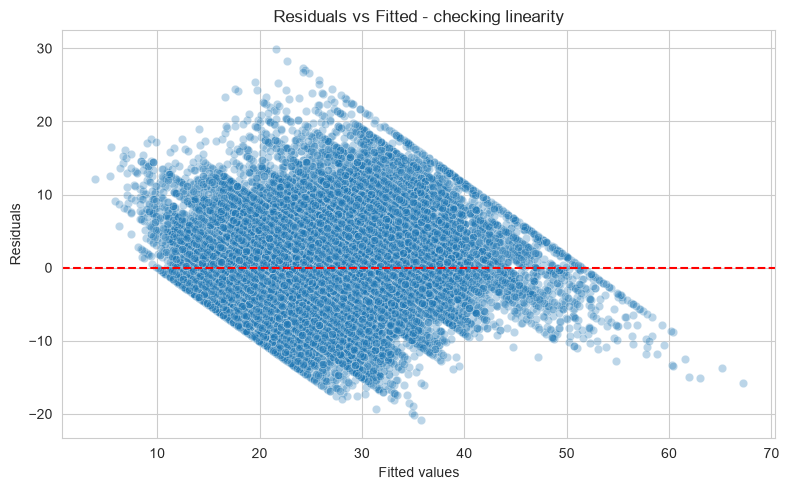

In [39]:
# 12c. Linearity - residuals vs fitted should show NO systematic curve/pattern
residuals = ols_model.resid
fitted = ols_model.fittedvalues

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values"); plt.ylabel("Residuals")
plt.title("Residuals vs Fitted - checking linearity")
plt.tight_layout(); plt.show()

In [40]:
# 12d. Independence of errors - Durbin-Watson statistic (ideal ~ 2; range 0-4)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.3f}  (~2.0 = no autocorrelation)")

Durbin-Watson statistic: 1.995  (~2.0 = no autocorrelation)


Jarque-Bera stat: 580.44   p-value: 9.098e-127   skew: 0.302   kurtosis: 3.133


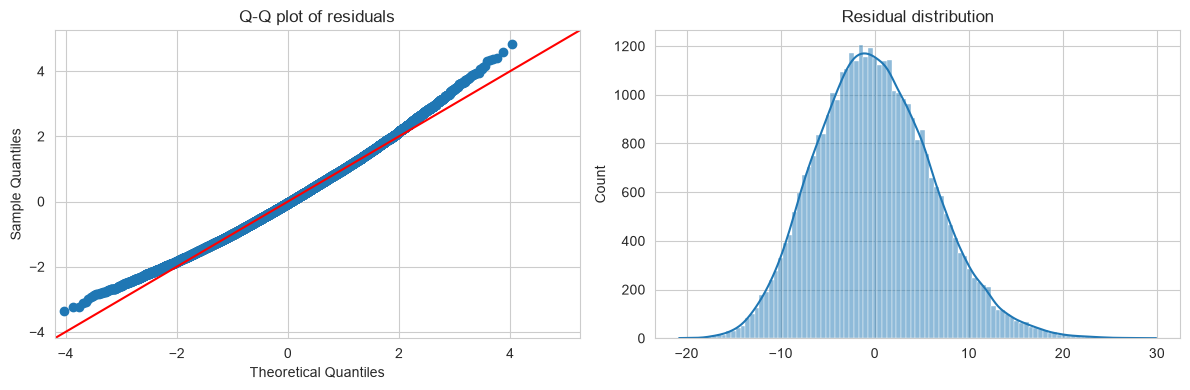

In [41]:
# 12f. Normality of residuals - Jarque-Bera test + Q-Q plot
from statsmodels.stats.stattools import jarque_bera
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)
print(f"Jarque-Bera stat: {jb_stat:.2f}   p-value: {jb_pvalue:.4g}   skew: {skew:.3f}   kurtosis: {kurtosis:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sm.qqplot(residuals, line="45", fit=True, ax=axes[0])
axes[0].set_title("Q-Q plot of residuals")
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual distribution")
plt.tight_layout(); plt.show()

## **14. Building the linear model**


In [42]:
def adjusted_r2(y_true, y_pred, n_features=X_train.shape[1]):
    r2 = r2_score(y_true, y_pred)
    n_samples = len(y_true)
    return 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)

In [43]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

print("R2  :", r2_score(y_test, y_pred))
print("Adj R2  :", adjusted_r2(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("MAE :", mean_absolute_error(y_test, y_pred))

R2  : 0.5619791108661975
Adj R2  : 0.5609677377302096
RMSE: 6.200030381088954
MAE : 4.923957518793168


## **15. Conclusion**

This project demonstrates a **complete end-to-end machine learning workflow for predicting Zomato food delivery time using Linear Regression**. Starting with the **raw dataset, I performed data exploration, data cleaning, missing value imputation, feature engineering, outlier detection and treatment, categorical feature encoding, feature scaling, and finally trained and evaluated a Linear Regression model.**

Throughout the project, I followed a structured approach by **first understanding the data through Exploratory Data Analysis (EDA), analysing feature relationships using correlation analysis, engineering meaningful features such as delivery distance, and validating the assumptions of Linear Regression before building the final model**. This ensured that the model was both statistically valid and interpretable.

The **model was evaluated using standard regression metrics including R² Score, Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Adjusted R²**, providing a comprehensive assessment of its predictive performance. Beyond building a predictive model, this project highlights the importance of careful data preprocessing and feature engineering, which play a critical role in improving model quality.

Overall, **this project strengthened my understanding of the complete machine learning pipeline—from raw data preprocessing to model development, evaluation, and interpretation. As my primary portfolio project, it demonstrates my ability to work with real-world datasets, apply industry-standard data preprocessing techniques, and build a well-structured, reproducible regression solution using Python and the Scikit-learn ecosystem.**

In [51]:
# Save the model and related artifacts for later use in the web app
import joblib

# 1) the trained model
joblib.dump(lr, 'zomato_model.pkl')

# 2) the scaler fit on X_train
joblib.dump(scaler, 'zomato_scaler.pkl')

# 3) exact column order the model expects
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, 'zomato_feature_columns.pkl')

# 4) IQR bounds used for capping
iqr_bounds_dict = {}
for col in ['distance_km', 'Delivery_person_Age', 'Delivery_person_Ratings']:
    lower, upper = iqr_bounds(df_cln[col])
    iqr_bounds_dict[col] = (lower, upper)
joblib.dump(iqr_bounds_dict, 'zomato_iqr_bounds.pkl')

# 5) real category options
category_options = {
    "Weather_conditions": sorted(df2["Weather_conditions"].unique().tolist()),
    "Type_of_order": sorted(df2["Type_of_order"].unique().tolist()),
    "Type_of_vehicle": sorted(df2["Type_of_vehicle"].unique().tolist()),
    "City": sorted(df2["City"].unique().tolist()),
}
joblib.dump(category_options, 'zomato_category_options.pkl')

# 6) model performance metrics  <-- ADD THIS PART
metrics = {
    "r2": r2_score(y_test, y_pred),
    "adj_r2": adjusted_r2(y_test, y_pred),
    "rmse": mean_squared_error(y_test, y_pred) ** 0.5,
    "mae": mean_absolute_error(y_test, y_pred),
}
joblib.dump(metrics, 'zomato_metrics.pkl')

print("Saved 6 files.")

Saved 6 files.
